# SVM Classification

В этом ноутбуке разберём:
- идею **margin** (отступа)
- линейный SVM
- SVM с разными ядрами: `linear` (линейное), `poly` (полиномиальное), `rbf` (гибкая нелинейная граница)
- влияние параметров **C** и **gamma**
- функцию потерь **Hinge Loss**
- метрики: Accuracy, Precision, Recall, F1, ROC-AUC

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

## 1. Идея Margin

SVM ищет такую разделяющую прямую (гиперплоскость), у которой **отступ (margin)** до ближайших точек обоих классов максимален. Эти ближайшие точки называют **опорными векторами (support vectors)**.

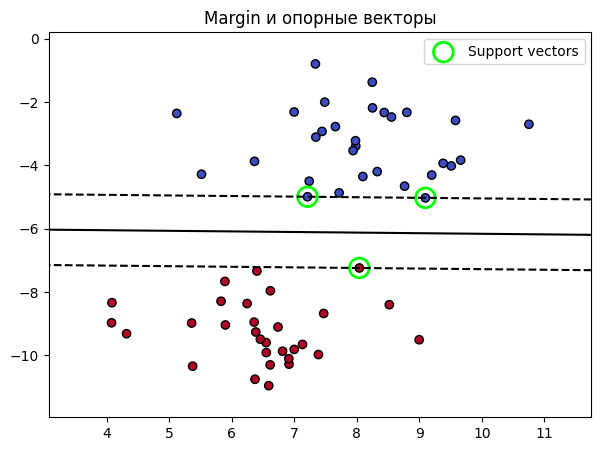

In [14]:
X, y = make_blobs(n_samples=60, centers=2, random_state=6, cluster_std=1.1)

clf = SVC(kernel='linear', C=1000)
clf.fit(X, y)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k',
            linestyles=['--','-','--'])
plt.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
            s=200, facecolors='none', edgecolors='lime', linewidths=2,
            label='Support vectors')
plt.title('Margin и опорные векторы')
plt.legend()
plt.show()

Сплошная линия — разделяющая граница, пунктир — края margin. Зелёные кружки — support vectors.

## 2. Линейный SVM

In [15]:
X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           class_sep=1.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

lin_svm = SVC(kernel='linear', C=1).fit(X_train_s, y_train)
print('Train accuracy:', lin_svm.score(X_train_s, y_train))
print('Test  accuracy:', lin_svm.score(X_test_s, y_test))

Train accuracy: 0.9619047619047619
Test  accuracy: 0.9666666666666667


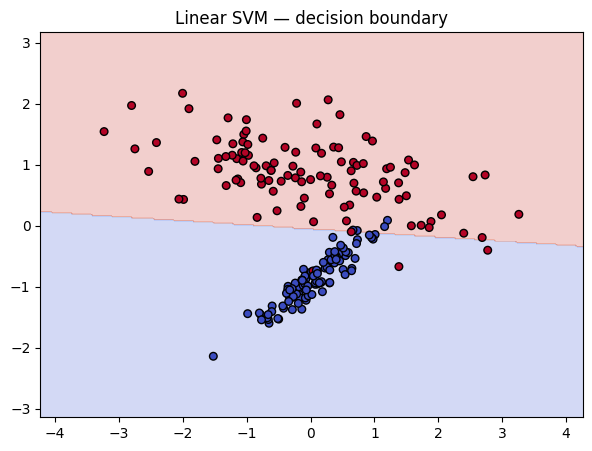

In [16]:
def plot_decision_boundary(clf, X, y, title=''):
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                         np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=30)
    plt.title(title)

plot_decision_boundary(lin_svm, X_train_s, y_train, 'Linear SVM — decision boundary')
plt.show()

## 3. SVM с разными ядрами

Когда данные **не** разделимы прямой, помогают нелинейные ядра.

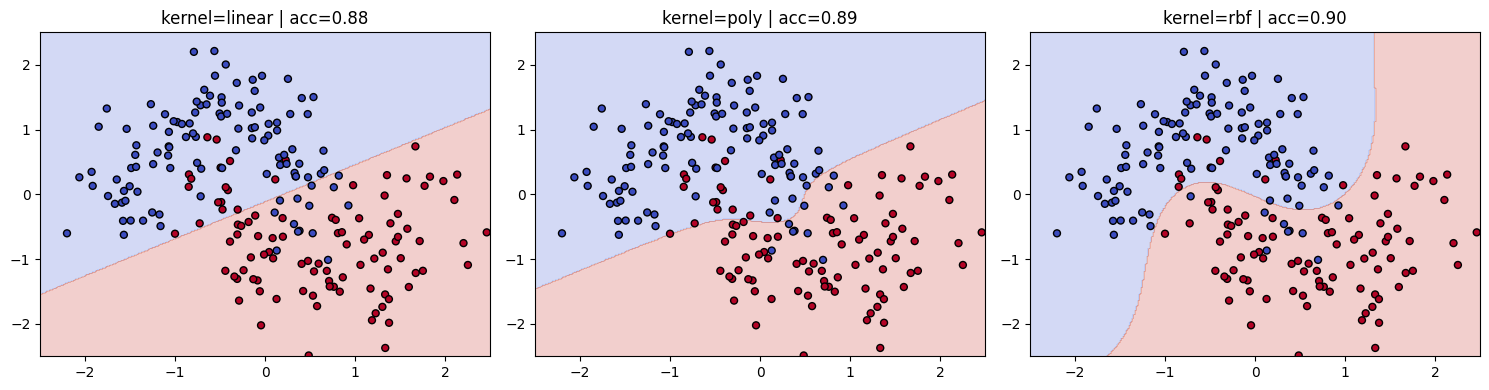

In [17]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train); X_test_s = scaler.transform(X_test)

kernels = ['linear', 'poly', 'rbf']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, kernels):
    clf = SVC(kernel=k, C=1, gamma='scale', degree=3).fit(X_train_s, y_train)
    acc = clf.score(X_test_s, y_test)
    xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300), np.linspace(-2.5, 2.5, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X_train_s[:,0], X_train_s[:,1], c=y_train, cmap='coolwarm', edgecolors='k', s=25)
    ax.set_title(f'kernel={k} | acc={acc:.2f}')

plt.tight_layout()
plt.show()

## 4. Влияние параметров C и gamma

- **C** — штраф за ошибки. Большое C → меньше ошибок, но узкий margin (риск переобучения).
- **gamma** (для `rbf`) — насколько "локально" работает каждая точка. Большое gamma → граница изгибается под отдельные точки.

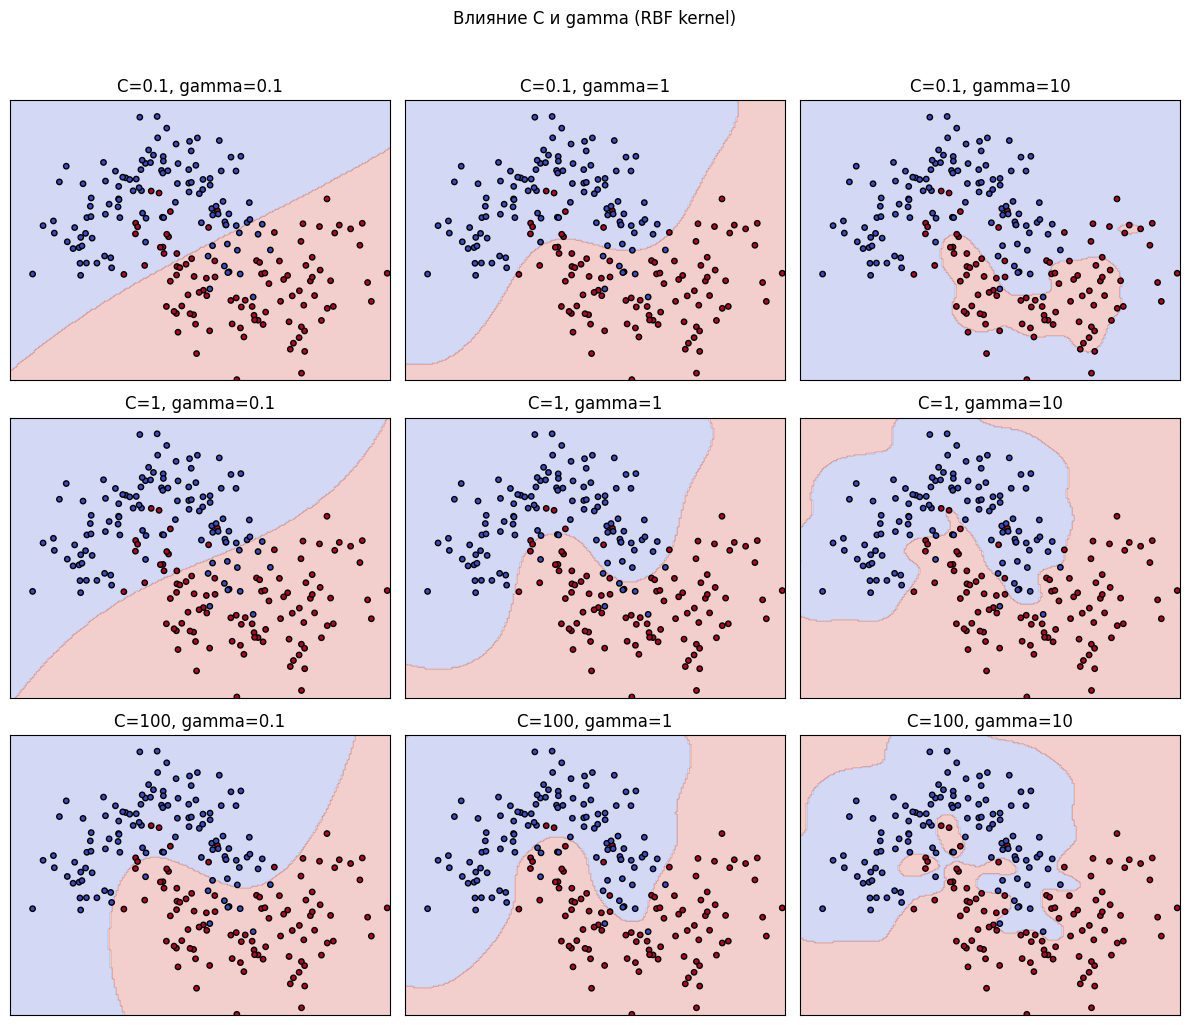

In [18]:
Cs = [0.1, 1, 100]
gammas = [0.1, 1, 10]

fig, axes = plt.subplots(len(Cs), len(gammas), figsize=(12, 10))
for i, C in enumerate(Cs):
    for j, g in enumerate(gammas):
        clf = SVC(kernel='rbf', C=C, gamma=g).fit(X_train_s, y_train)
        xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax = axes[i, j]
        ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
        ax.scatter(X_train_s[:,0], X_train_s[:,1], c=y_train, cmap='coolwarm', edgecolors='k', s=15)
        ax.set_title(f'C={C}, gamma={g}')
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Влияние C и gamma (RBF kernel)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Hinge Loss

$$L(y, f(x)) = \max(0,\; 1 - y \cdot f(x))$$

где $y \in \{-1, +1\}$, а $f(x)$ — выход модели. Если точка лежит правильно и за пределами margin — потеря 0; иначе она линейно растёт.

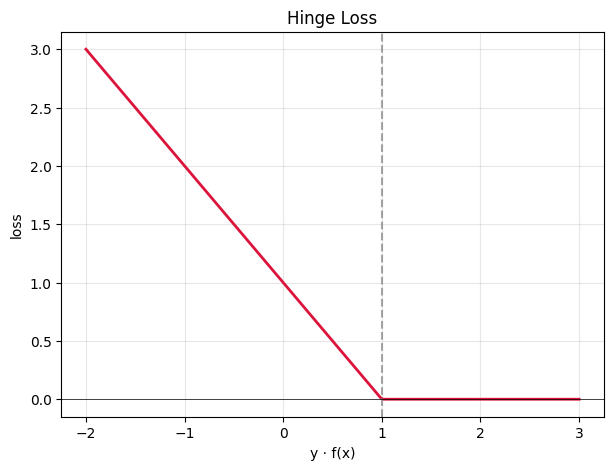

In [19]:
z = np.linspace(-2, 3, 200)
hinge = np.maximum(0, 1 - z)

plt.plot(z, hinge, lw=2, color='crimson')
plt.axvline(1, ls='--', color='gray', alpha=0.7)
plt.axhline(0, color='black', lw=0.5)
plt.title('Hinge Loss')
plt.xlabel('y · f(x)'); plt.ylabel('loss')
plt.grid(alpha=0.3)
plt.show()

## 6. Метрики качества

In [20]:
model = SVC(kernel='rbf', C=1, gamma='scale', probability=True).fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_proba),
}
pd.DataFrame(metrics, index=['SVM (rbf)']).round(3)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
SVM (rbf),0.9,0.906,0.923,0.914,0.983


##7. Метрики — bar chart

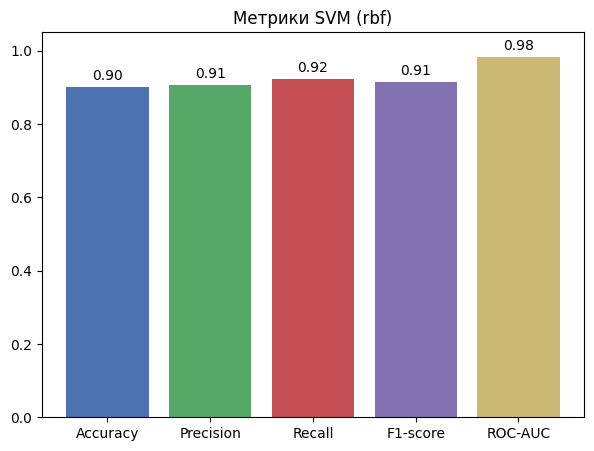

In [21]:
plt.bar(metrics.keys(), metrics.values(),
        color=['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974'])
plt.ylim(0, 1.05)
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.title('Метрики SVM (rbf)')
plt.show()

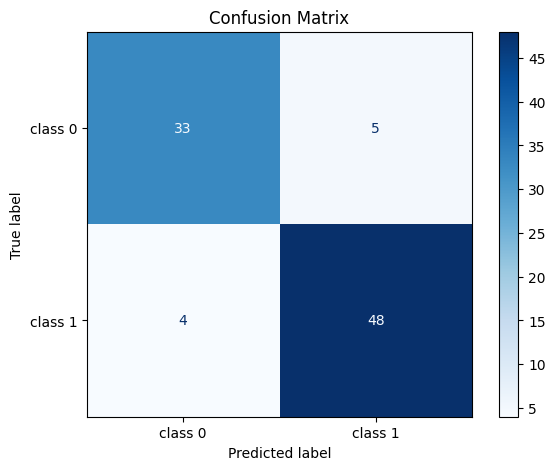

In [22]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['class 0','class 1']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

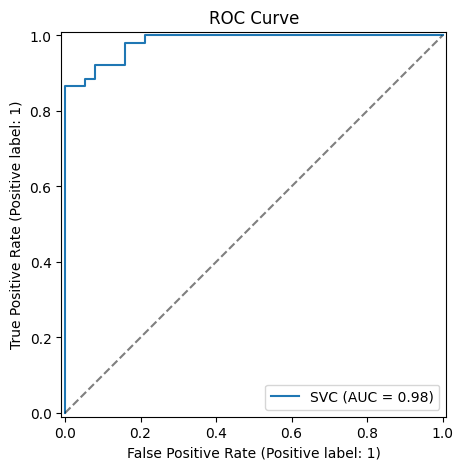

In [23]:
RocCurveDisplay.from_estimator(model, X_test_s, y_test)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.title('ROC Curve')
plt.show()

#**Общий итог:**

- SVM максимизирует margin между классами — устойчив на небольших датасетах.
- `linear` хорош для линейно разделимых данных, `rbf` — универсальный, `poly` — для полиномиальных закономерностей.
- **C** контролирует жёсткость margin, **gamma** — гибкость границы (для rbf).
- Hinge Loss штрафует точки внутри margin или с неверным классом.
- Для оценки используем не только accuracy, но и precision/recall/F1/ROC-AUC.